## Assignment 11

### Imports

In [20]:
import pandas as pd
import numpy as np
import os
import random
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score
import mlflow
from datetime import datetime
from itertools import product
from sklearn.model_selection import KFold
import torch.optim as optim
import json
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device("cpu")
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

## Functions to manage data

In [21]:
def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files
    

def input_target_split_start_stop(dataframe):

    joints = [
        "head", "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot" ]

    input_col_names = []

    for joint in joints:
        input_col_names += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    X = dataframe[input_col_names].copy()
    y = dataframe[["running_video"]].copy()

    return X, y

def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined


## 1. Kinect data

### Manage data, split etc

In [22]:
data_folder = "../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop"

training_prop = 0.9
validation_prop = 0
train_files, test_files = split_csvfiles(data_folder, random_seed, training_prop, validation_prop)

# Load in combined dataframe of all the files kept in the specific split
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)

# Split input (x, y, z) and target (running_video)
x_train, y_train = input_target_split_start_stop(train_data)
x_test, y_test = input_target_split_start_stop(test_data)

# Normalize data with the training scale
scaler = StandardScaler()
x_train_np = x_train.values
x_test_np = x_test.values

x_train_scaled = scaler.fit_transform(x_train_np)
x_test_scaled = scaler.transform(x_test_np)  # use same scaler

# Convert to tensors for the 
x_train = torch.tensor(x_train_scaled, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device)


### Functions for model management

In [23]:
def save_candidate_model(model, model_name, candidates_dir):
    path = os.path.join(candidates_dir, f"{model_name}.pt")
    torch.save(model.state_dict(), path)
    print(f"Saved candidate model: {path}")
    return path

def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")

    if not os.path.exists(path):
        return None

    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

def save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters):
    model_path = os.path.join(champion_dir, "champion_model.pt")
    info_path = os.path.join(metadata_dir, "champion_info.json")

    # Save model weights
    torch.save(model.state_dict(), model_path)

    # Save metadata
    info = {
        "model_name": model_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "f1": float(f1),
        "recall": float(recall),
        "precision": float(precision),
        "hyperparameters": hyperparameters
    }

    with open(info_path, "w") as f:
        json.dump(info, f, indent=2)

    print("New champion model saved!")


def update_champion(metadata_dir, champion_dir, model, model_name, f1, recall, precision, hyperparameters):
    current = load_champion_info(metadata_dir)

    if current is None:
        print("No champion found --> saving first model")
        save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters)

    elif f1 > current["f1"]:
        print(f"New model is better (f1 {f1} > {current['f1']})")
        save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters)

    else:
        print(f"Model NOT better (f1 {f1} < {current['f1']})")

### Functions for modelling with a MLP, dense layers with ADAM optimization

In [24]:
# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight) # good for ReLU
        nn.init.zeros_(m.bias)

# Define squat classifier class
class Squatclassifier(nn.Module):
    def __init__(self, input_size, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []

        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        act = activations[activation]
        prev_size = input_size

        # Hidden layers
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(act)

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        # Output layer- 1 neuron
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)
    
    def forward(self, X):
        return self.network(X)
        

# Initializes a squatclassifier model based on a configuration
def build_model(config):
    return Squatclassifier(
        input_size=config["input_size"],
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Train the model
def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    epochs = config["epochs"]

    best_val_f1 = 0
    best_state = None
    patience = 10
    epochs_no_improve = 0

    # reshape targets
    y_train = y_train.view(-1, 1)
    y_val = y_val.view(-1, 1)

    # Training loop (full-batch, batching doesn't make anything faster for me)
    for epoch in range(epochs):

        # Full batch training
        model.train()
        optimizer.zero_grad()

        logits = model(x_train)          # one big forward pass
        loss = loss_fn(logits, y_train)

        loss.backward()
        optimizer.step()

        # Validation
        model.eval()

        with torch.no_grad():
            val_logits = model(x_val)
            probs = torch.sigmoid(val_logits)
            preds = (probs > 0.5).float()

            val_f1 = f1_score(
                y_val.cpu().numpy(),
                preds.cpu().numpy()
            )

        # EARLY STOPPING on F1
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    return best_val_f1, best_state


def cross_validation(config, X, Y, k):

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_models = []

    # Train and evaluate on each fold
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        x_train = X[train_idx].to(device)
        y_train = Y[train_idx].to(device)

        x_val = X[val_idx].to(device)
        y_val = Y[val_idx].to(device)

        # Build model
        model = build_model(config)


        val_f1, best_state = train_one_model(
            model,
            config,
            x_train,
            y_train,
            x_val,
            y_val,
            # Binary Cross Entropy/Log Loss
            loss_fn=nn.BCEWithLogitsLoss()
        )

        fold_scores.append(val_f1)
        fold_models.append(best_state)


    avg_f1 = sum(fold_scores) / len(fold_scores)


    return {
        "cv_mean_f1": avg_f1,
        "fold_scores": fold_scores,
        "fold_models": fold_models
    }

## Tuning of model using 10 fold Cross Validation

In [25]:
# Define search space 
param_grid = {"layers": [[128, 64], [256, 128, 32]],
              "lr": [0.005, 0.0001],
              "dropout": [0, 0.1],
              "activation": ["relu", "leaky_relu"],
              "epochs": [100, 200],
              "input_size": x_train.shape[1]
            }


# Create the combinations of the parameters and run training using k-fold cv on grid
trial = 0
best_score = 0
best_config = None

for values in product(param_grid["layers"], param_grid["lr"], param_grid["dropout"], param_grid["activation"], param_grid["epochs"]):
    config = {"layers": values[0], "lr": values[1], "dropout": values[2], "activation": values[3], "epochs": values[4], "input_size": param_grid["input_size"]}

    print(f"\nTrial {trial}")
    print(config)

    # Run 10 fold cross validation
    k = 10
    results = cross_validation(config, x_train, y_train, k)
    cv_score = results["cv_mean_f1"]
    print(f"CV mean f1: {cv_score}")

    # Track best config
    if cv_score > best_score:
        best_score = cv_score
        best_config = config

    trial += 1


Trial 0
{'layers': [128, 64], 'lr': 0.005, 'dropout': 0, 'activation': 'relu', 'epochs': 100, 'input_size': 39}
CV mean f1: 0.9618417632326104

Trial 1
{'layers': [128, 64], 'lr': 0.005, 'dropout': 0, 'activation': 'relu', 'epochs': 200, 'input_size': 39}
CV mean f1: 0.963377019172184

Trial 2
{'layers': [128, 64], 'lr': 0.005, 'dropout': 0, 'activation': 'leaky_relu', 'epochs': 100, 'input_size': 39}
CV mean f1: 0.9595151007043092

Trial 3
{'layers': [128, 64], 'lr': 0.005, 'dropout': 0, 'activation': 'leaky_relu', 'epochs': 200, 'input_size': 39}
CV mean f1: 0.9637535143186527

Trial 4
{'layers': [128, 64], 'lr': 0.005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 100, 'input_size': 39}
CV mean f1: 0.9514398184829232

Trial 5
{'layers': [128, 64], 'lr': 0.005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 200, 'input_size': 39}
CV mean f1: 0.9642854877827908

Trial 6
{'layers': [128, 64], 'lr': 0.005, 'dropout': 0.1, 'activation': 'leaky_relu', 'epochs': 100, 'input_size': 39}


## Re-train best configuration found in gridsearch and evaulate against test data

Best config: {'layers': [256, 128, 32], 'lr': 0.005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 200, 'input_size': 39}
TEST RESULTS
F1: 0.9239302694136292
Precision: 0.9098712446351931
Recall: 0.938430583501006
Accuracy: 0.893717132576806

Confusion Matrix:


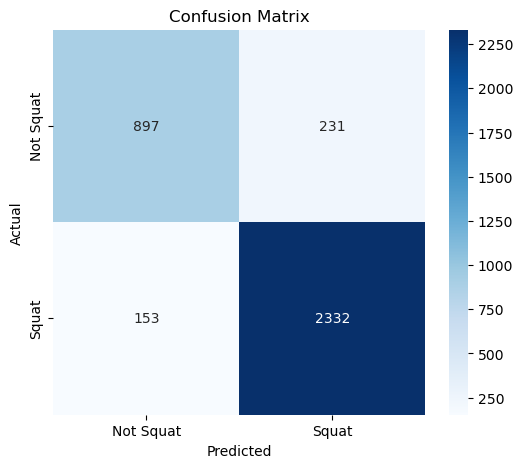

No champion found --> saving first model
New champion model saved!


In [26]:

print(f"Best config: {best_config}")

# Rebuild best model from cross validation grid search
final_model = build_model(best_config)

# Make split for the retraining s.t model isn't overfitted to the training data
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)


# Retrain best config from the cross validation gridsearch
_, best_state = train_one_model(final_model, best_config, x_tr, y_tr, x_val, y_val, loss_fn = nn.BCEWithLogitsLoss())

# Load weights from training
final_model.load_state_dict(best_state)

# Evaluate against test set
final_model.eval()
with torch.no_grad():
    logits = final_model(x_test.to(device))
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    f1 = f1_score(y_test.cpu(), preds.cpu())
    precision = precision_score(y_test.cpu(), preds.cpu())
    recall = recall_score(y_test.cpu(), preds.cpu())
    accuracy = accuracy_score(y_test.cpu(), preds.cpu())

    cm = confusion_matrix(y_test.cpu(), preds.cpu())

print("TEST RESULTS")
print(f"F1: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")
print("\nConfusion Matrix:")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Squat", "Squat"],
            yticklabels=["Not Squat", "Squat"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# Update champion if best config from the grid search performs better than previous champion on test data
model_root = "../binary_classificator_models"

candidates_dir = os.path.join(model_root, "candidates")
champion_dir = os.path.join(model_root, "champion")
metadata_dir = os.path.join(model_root, "metadata")

champion_model_path = os.path.join(champion_dir, "champion_model.pt")
champion_info_path = os.path.join(metadata_dir, "champion_info.json")

model_name = "final_model"


update_champion(
    metadata_dir,
    champion_dir,
    final_model,
    model_name,
    f1,
    recall,
    precision,
    best_config
)